# Receiver 1 recalibration 2015_09

This is primary receiver calibration data and coeffecients used to calibrate the lowband 1 data used in Bowman et al 2018. 

We follow memo Loco memo #92, for the choices of: 
a.) Load resistance values
b.) spectra files
c.) S11 folders
d.) cterms & wterms

In [1]:
import edges_cal as ec
from edges_io import io
import matplotlib.pyplot as plt
import numpy as np
%load_ext autoreload
%autoreload 2
import h5py

from edges_cal.cal_coefficients import perform_term_sweep

In [3]:
path = '/data5/edges/data/CalibrationObservations/Receiver01/'

In [4]:
calobs = ec.CalibrationObservation(
    path+"Receiver01_25C_2015_09_02_040_to_200MHz/", 
    f_low=50.0,
    f_high=100.0,
    run_num={"receiver_reading": 6},
    repeat_num=1,
    cterms=6,
    wterms=5,
    load_kwargs= {"t_load": 300, "t_load_ns": 1000.0},
    load_spectra = {
        "hot_load": {"ignore_times_percent": 10},
        "ambient": {"ignore_times_percent": 7},
        "open": {"ignore_times_percent": 7},
        "short": {"ignore_times_percent": 7},
    },
    load_s11s = {"lna":{'n_terms': 11, 'model_type': 'polynomial'}}
)



In [5]:
calobs.write("/data4/nmahesh/edges/edges-field-levels/alans_noise_waves_2015.h5")

In [52]:
fm = ec.modelling.Polynomial(n_terms=27, transform=ec.modelling.UnitTransform(range=(alan_data[0,0],alan_data[1433,0])))
model = fm.at(x = alan_data[:,0]).fit(ydata = alan_data[:,1])
real = model.evaluate(calobs.freq.freq)
model = fm.at(x = alan_data[:,0]).fit(ydata = alan_data[:,2])
imag = model.evaluate(calobs.freq.freq)

#model = mdl.Polynomial(
#            n_terms=10, transform=mdl.UnitTransform(range=(f_orig.min(), f_orig.max()))
#        )

#    model = mdl.ComplexRealImagModel(real=model, imag=model)

In [53]:
calobs_new = calobs.inject(lna_s11=real+1j*imag)

In [57]:
calobs.lna_s11

array([-0.00126906+0.02175159j, -0.00126549+0.02174946j,
       -0.00126193+0.02174733j, ..., -0.00525982+0.01278441j,
       -0.00526114+0.01278562j, -0.00526246+0.01278683j])

In [58]:
calobs_new.lna_s11

array([-0.00086019+0.02192975j, -0.00085698+0.02192693j,
       -0.00085378+0.02192412j, ..., -0.00470025+0.0133464j ,
       -0.00470205+0.01334737j, -0.00470384+0.01334834j])

In [55]:
calobs_new.write("/data4/nmahesh/edges/edges-field-levels/alans_noise_waves_2015_lnas11m.h5")

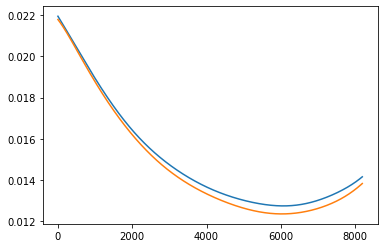

In [56]:
plt.plot(np.abs(calobs_new.lna_s11))
plt.plot(np.abs(calobs.lna_s11))

In [6]:
calobs2 = ec.CalibrationObservation(path=path+"Receiver01_25C_2015_09_02_040_to_200MHz/",
                                    f_low = 50, f_high= 100, cterms=7,wterms=7, run_num={"receiver_reading":1},
                                    repeat_num=1,load_s11s = {"open": {"n_terms":151}})

In [11]:
raul_data = np.loadtxt('/home/smurray/data4/Projects/radio/EOR/Edges/bayesian-calibration/for_steven_low_band_1_extended_GP_calibration_parameters.txt')

In [7]:
cal_2015_09 = ec.Calibration('/home/smurray/data4/Projects/radio/EOR/Edges/bayesian-calibration/calfile_almost_rauls_better.h5')

In [3]:
alan_data_re = ec.Calibration('/data4/nmahesh/edges/edges-field-levels/alans_noise_waves_2015.h5')

In [9]:
alan_data = np.loadtxt('/data4/nmahesh/edges/code_from_alan/specal.txt',usecols=(1,3,4,6,8,10,12,14))

(0, 2000)

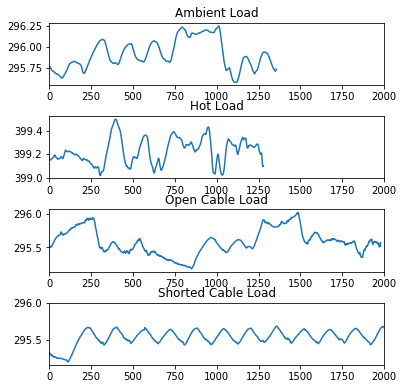

In [6]:
plt.figure(figsize=(6,8))
plt.subplots_adjust(hspace=0.5)
plt.subplot(5,1,1)
plt.plot(calobs2.ambient.spectrum.thermistor_temp)
plt.title('Ambient Load')
plt.xlim([0,2000])

plt.subplot(5,1,2)
plt.plot(calobs2.hot_load.spectrum.thermistor_temp)
plt.title('Hot Load')
plt.xlim([0,2000])

plt.subplot(5,1,3)
plt.plot(calobs2.open.spectrum.thermistor_temp)
plt.title('Open Cable Load')
plt.xlim([0,2000])

plt.subplot(5,1,4)
plt.plot(calobs2.short.spectrum.thermistor_temp)
plt.title('Shorted Cable Load')
plt.xlim([0,2000])

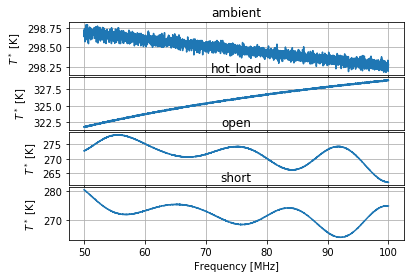

In [7]:
calobs2.plot_raw_spectra();

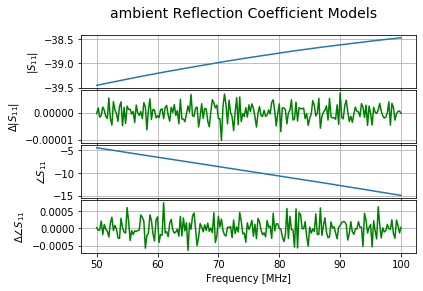

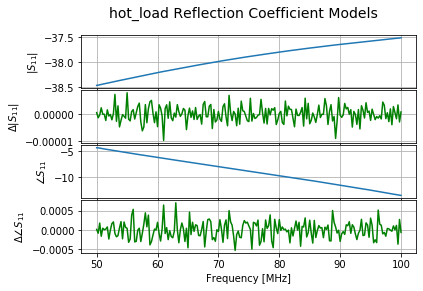

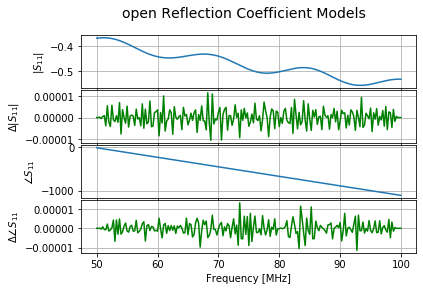

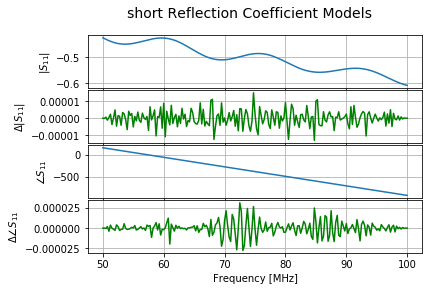

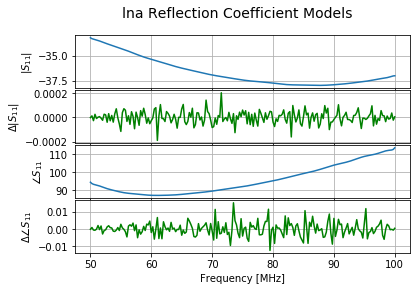

In [8]:
calobs2.plot_s11_models();

In [32]:
ch=calobs2.open.from_path(path=path+"Receiver01_25C_2015_09_02_040_to_200MHz", load_name='open')

In [35]:
calobs2.update(cterms=6)

In [41]:
calobs2.io.get_base_files?

<Figure size 2000x2000 with 0 Axes>

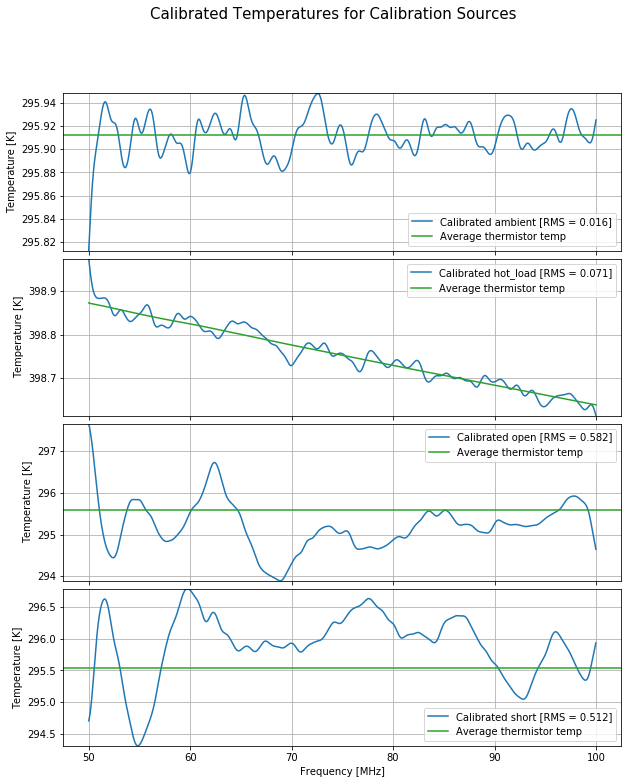

In [76]:
fig = plt.figure(figsize=(2,2),dpi=1000)
calobs.plot_calibrated_temps(fig=fig);

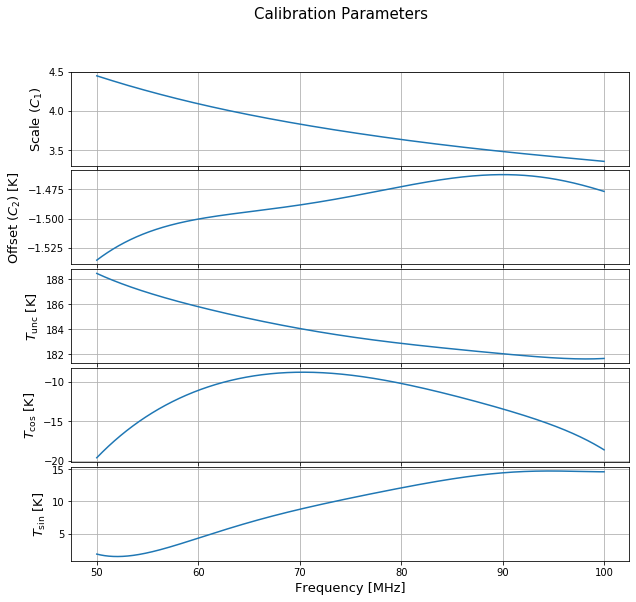

In [8]:
calobs2.plot_coefficients();

In [14]:
calobs2.write('/data4/nmahesh/edges/cal_file_Rcv01_2015_09.h5')      

In [9]:
rcv1_2015 = ec.Calibration('/data4/nmahesh/edges/edges-field-levels/low1_cal_files/Rcv_2017_05.h5')

# Comparison with Raul's data

(50, 100)

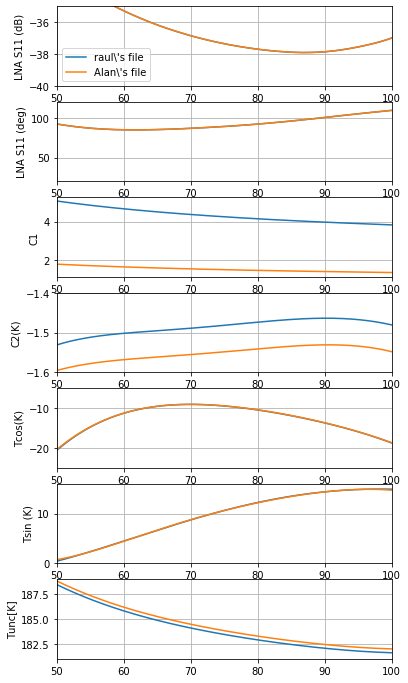

In [14]:
plt.figure(figsize=(6,12))
plt.subplot(7,1,1)
#plt.plot(rcv1_2015.freq.freq,20*np.log10(np.abs(rcv1_2015.lna_s11())),label='Nive - cal')
#plt.plot(cal_2015_09.freq.freq,20*np.log10(np.abs(cal_2015_09.lna_s11())),label='edges-cal-raul')
#plt.plot(alan_data_re.freq.freq,20*np.log10(np.abs(alan_data_re.lna_s11())),label='edges-cal-alan')
plt.plot(raul_data[:,0],20*np.log10(np.abs(raul_data[:,1]+1j*raul_data[:,2])),label=r'raul\'s file')
plt.plot(alan_data[:,0],20*np.log10(np.abs(alan_data[:,1]+1j*alan_data[:,2])),label=r'Alan\'s file')
plt.grid()
plt.legend()
plt.ylabel('LNA S11 (dB)')
plt.ylim([-40,-35])
plt.xlim([50,100])

plt.subplot(7,1,2)
#plt.plot(rcv1_2015.freq.freq,(np.angle(rcv1_2015.lna_s11()))*180/np.pi)
#plt.plot(cal_2015_09.freq.freq,np.angle(cal_2015_09.lna_s11())*180/np.pi)
#plt.plot(alan_data_re.freq.freq,np.angle(alan_data_re.lna_s11())*180/np.pi)
plt.plot(raul_data[:,0],np.angle(raul_data[:,1]+1j*raul_data[:,2])*180/np.pi)
plt.plot(alan_data[:,0],np.angle(alan_data[:,1] + 1j*alan_data[:,2])*180/np.pi)
plt.ylim([20,120])
plt.grid()
plt.ylabel('LNA S11 (deg)')
plt.xlim([50,100])

plt.subplot(7,1,3)
#plt.plot(rcv1_2015.freq.freq,(rcv1_2015.C1()))
#plt.plot(cal_2015_09.freq.freq,(cal_2015_09.C1()))
#plt.plot(alan_data_re.freq.freq,(alan_data_re.C1()))
plt.plot(raul_data[:,0],raul_data[:,3])
plt.plot(alan_data[:,0],alan_data[:,3])
#plt.ylim([2,6])
plt.grid()
plt.ylabel('C1')
plt.xlim([50,100])

plt.subplot(7,1,4)
#plt.plot(rcv1_2015.freq.freq,(rcv1_2015.C2()))
#plt.plot(cal_2015_09.freq.freq,(cal_2015_09.C2()))
#plt.plot(alan_data_re.freq.freq,(alan_data_re.C2()))
plt.plot(raul_data[:,0],raul_data[:,4])
plt.plot(alan_data[:,0],alan_data[:,4])
plt.ylim([-1.6,-1.4])
plt.grid()
plt.ylabel('C2(K)')
plt.xlim([50,100])

plt.subplot(7,1,5)
#plt.plot(rcv1_2015.freq.freq,(rcv1_2015.Tcos()))
#plt.plot(cal_2015_09.freq.freq,(cal_2015_09.Tcos()))
#plt.plot(alan_data_re.freq.freq,(alan_data_re.Tcos()))
plt.plot(raul_data[:,0],raul_data[:,6])
plt.plot(alan_data[:,0],alan_data[:,6])
plt.ylim([-25,-5])
plt.grid()
plt.ylabel('Tcos(K)')
plt.xlim([50,100])

plt.subplot(7,1,6)
#plt.plot(rcv1_2015.freq.freq,(rcv1_2015.Tsin()))
#plt.plot(cal_2015_09.freq.freq,(cal_2015_09.Tsin()))
#plt.plot(alan_data_re.freq.freq,(alan_data_re.Tsin()))
plt.plot(raul_data[:,0],raul_data[:,7])
plt.plot(alan_data[:,0],alan_data[:,7])
plt.ylim([0,16])
plt.grid()
plt.ylabel('Tsin (K)')
plt.xlim([50,100])

plt.subplot(7,1,7)
#plt.plot(rcv1_2015.freq.freq,(rcv1_2015.Tunc()))
#plt.plot(cal_2015_09.freq.freq,(cal_2015_09.Tunc()))
#plt.plot(alan_data_re.freq.freq,(alan_data_re.Tunc()))
plt.plot(raul_data[:,0],raul_data[:,5])
plt.plot(alan_data[:,0],alan_data[:,5])
plt.ylim([181,189])
plt.grid()
plt.ylabel('Tunc[K]')
plt.xlim([50,100])


In [16]:
alan_data_re.t_load_ns

1000.0

In [17]:
cal_2015_09.t_load_ns

350